# Markov Regime-Switching Volatility Forecasting for the S&P 500

## Introduction and Motivation

Most of quantitative finance treats markets as approximately rational, informationally efficient systems. For price direction, that assumption holds up reasonably well empirically. Daily returns are close to unpredictable, consistent with the weak-form efficient market hypothesis and the random walk model of prices: if direction were reliably forecastable, that edge would already have been arbitraged away.

Volatility behaves differently, and that asymmetry is what makes it worth studying. While the sign of a price move is close to unpredictable, its magnitude is not — realized volatility exhibits strong positive autocorrelation, a stylized fact known as volatility clustering (Mandelbrot, 1963; Cont, 2001). A day of large moves is far more likely to be followed by another day of large moves than by a return to calm, regardless of which direction those moves take. This isn't really a claim about informational efficiency; it's closer to a claim about how slowly collective uncertainty and risk aversion decay once triggered. Volatility clustering is, in that sense, one of the more quantifiable fingerprints of market psychology embedded in otherwise efficient-looking price data — the part of markets that behaves less like an information-processing mechanism and more like a crowd working through fear at its own pace.

But that clustering is not uniform through time. Markets visibly alternate between distinct states: long, quiet stretches of low and stable volatility, punctuated by shorter, violent episodes of crisis. Models that assume a single, fixed set of dynamics — EWMA, GARCH, HAR — implicitly average across these states, and tend to break down precisely when accuracy matters most, during the transitions into and out of turmoil. This motivates a regime-switching approach: a latent Markov process that lets volatility dynamics differ across market states, and in doing so treats "calm" and "crisis" as the qualitatively different environments they are.

This project builds a volatility forecasting pipeline for the S&P 500 in two stages. The first establishes rigorous baselines — the classical econometric models used on trading desks (EWMA, GARCH, HAR-RV), followed by a machine-learning comparison — and finds, consistent with the literature, that added model complexity does not improve on a simple linear specification. The second stage extends this into a Markov regime-switching framework: a hidden Markov model detects latent volatility regimes and drives a regime-dependent forecaster, evaluated not only on point-forecast accuracy but on the risk-management metrics that volatility forecasts actually feed — Value-at-Risk and Expected Shortfall — where distinguishing calm from crisis matters most.

## Project Outline

**Stage 1 — Baselines**

1. **Data & target variable**: pull SPY OHLC data, construct a realized volatility series using the Garman-Klass range estimator

2. **Classical baselines**: EWMA, GARCH(1,1), and HAR-RV, evaluated out-of-sample via a chronological train/test split

3. **Machine learning**: linear regression, random forest, and gradient boosting, benchmarked against HAR-RV on identical footing; CV-scored stepwise selection to test whether added features carry signal

**Stage 2 — Regime-Switching Extension**

4. **Regime detection**: fit a Gaussian hidden Markov model to identify latent volatility regimes (calm / normal / stressed / panic), with the number of states selected by BIC; derive a continuous early-warning stress index

5. **Markov-Switching HAR**: extend HAR-RV so its dynamics switch by regime, and test whether regime-awareness improves out-of-sample forecasts

6. **Probabilistic forecasting**: simulate forward volatility paths through the regime chain (Monte Carlo) to produce predictive distributions and prediction intervals, rather than point forecasts alone

7. **Risk-management evaluation**: convert forecasts into Value-at-Risk and Expected Shortfall, and backtest tail accuracy with coverage tests (Kupiec, Christoffersen) — the axis where regime-switching is expected to matter most

**Evaluation**: Stage 1 models are compared on out-of-sample RMSE; Stage 2 adds risk-management metrics (VaR coverage, Expected Shortfall), so the regime model is judged on how well it captures tail risk, not just average error.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

from volforecast.baselines import (
    ewma_vol,
    fit_har,
    garch_conditional_vol,
    garch_rolling_forecast,
    har_predict,
    rmse,
)
from volforecast.config import NOTEBOOK_DATA_END, REGIME_LABELS, SPLIT_DATE
from volforecast.data import load_spy_data
from volforecast.features import har_design

pd.set_option("display.width", 100)


## Data & Realized Volatility

I'm using SPY daily OHLC data from 2015 onward, which spans several distinct volatility regimes (the 2015 China deval/oil selloff, Feb 2018 "Volmageddon," the March 2020 COVID crash, and 2025's tariff-driven selloff) — important for training models that need to see both calm and crisis conditions.

Rather than using close-to-close returns, I estimate daily realized volatility with the **Garman-Klass estimator**, which uses the full OHLC range instead of just the closing price:

$$
\hat{\sigma}^2_{GK} = 0.5 (\ln(H/L))^2 - (2\ln2 - 1)(\ln(C/O))^2
$$

This is a more statistically efficient estimator than close-to-close squared returns because it incorporates intraday range information (a day that spiked and reverted looks volatile here, even if it closed flat). The result is annualized (×252 trading days) and expressed in percent — this `realized_vol` series is the target variable every model in this notebook is trying to forecast.

In [2]:
# One load, one dataset, for the whole notebook. The end date is pinned so this
# notebook stays reproducible as a research artifact; the live forecaster in
# src/volforecast/daily.py deliberately leaves it unset and pulls through today.
spy, returns = load_spy_data(end=NOTEBOOK_DATA_END)
rv = spy["realized_vol"].dropna()

print(f"{spy.index[0].date()} to {spy.index[-1].date()}  ({len(spy):,} trading days)")
print(f"Realized vol: mean {rv.mean():.1f}%, median {rv.median():.1f}%, max {rv.max():.1f}%")


2015-01-02 to 2026-07-31  (2,911 trading days)
Realized vol: mean 10.9%, median 8.7%, max 96.5%


## Model 1: EWMA (Exponentially Weighted Moving Average)

EWMA estimates today's variance as a decay-weighted average of past squared returns:

$$
\sigma^2_t = (1-\lambda)\sum_{i=0}^{\infty} \lambda^i r_{t-1-i}^2
$$

with $\lambda = 0.94$, the standard RiskMetrics convention for daily data. Higher $\lambda$ means slower decay (more weight on old data); lower $\lambda$ reacts faster to recent shocks. Unlike the models below, $\lambda$ isn't estimated from data — it's a fixed rule, which makes EWMA fast and simple but not adaptive to this specific asset's dynamics.

In [3]:
# EWMA, lambda = 0.94 (the RiskMetrics convention)
ewma_series = ewma_vol(returns)
ewma_series.tail()


Date
2026-07-27    12.001025
2026-07-28    11.672540
2026-07-29    12.823117
2026-07-30    14.013056
2026-07-31    13.869590
Name: ewma_vol, dtype: float64

## Model 2: GARCH(1,1)

GARCH generalizes EWMA by letting the data determine the decay dynamics instead of fixing them in advance:

$$
\sigma^2_t = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2
$$

Fit on the full sample, the model estimates $\omega = 0.041$, $\alpha = 0.171$, $\beta = 0.795$ — all highly significant (p < 0.001). $\alpha + \beta \approx 0.966$, indicating strong persistence: volatility shocks decay slowly, which is the mathematical signature of clustering.

Worth noting: the **mean model R² is 0.000** — this isn't a bug, it's the random walk hypothesis showing up empirically. The mean equation is trying to predict the *direction* of returns and essentially fails to, which is expected and healthy. The volatility model is a separate equation entirely, and it's the one doing real work here: direction is close to unpredictable, but the *size* of tomorrow's move is not.

In [4]:
garch_vol = garch_conditional_vol(returns)
garch_vol.tail()


Date
2026-07-27    12.594047
2026-07-28    11.691437
2026-07-29    10.965354
2026-07-30    14.813225
2026-07-31    17.107321
Name: garch_vol, dtype: float64

## Graph Analysis: Realized vs. EWMA vs. GARCH

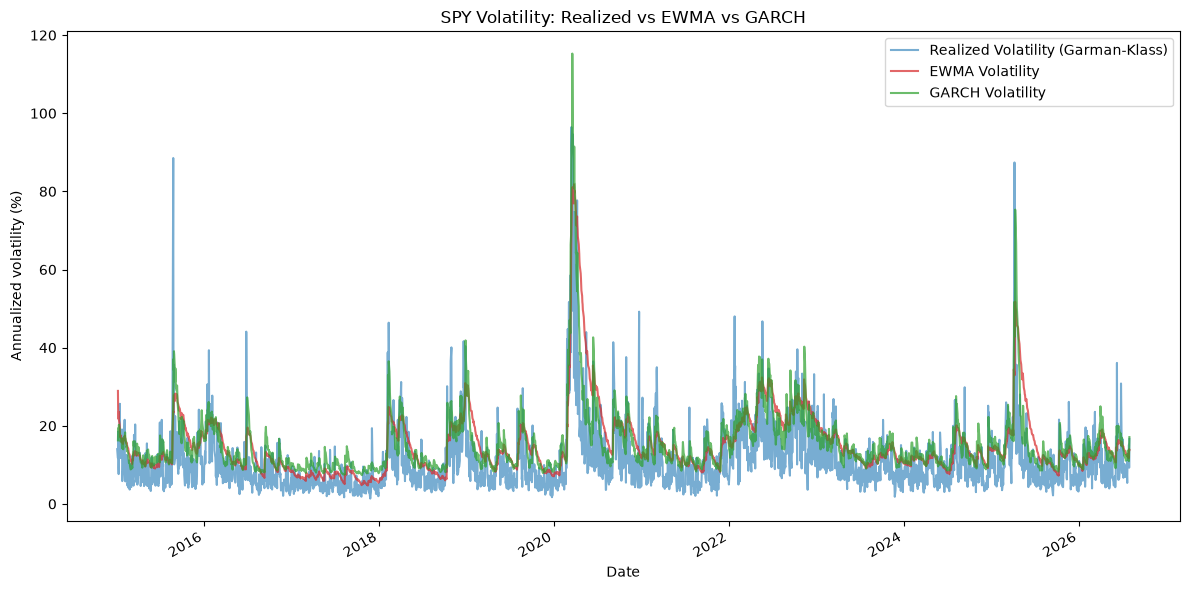

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
rv.plot(ax=ax, label="Realized Volatility (Garman-Klass)", color="tab:blue", alpha=0.6)
ewma_series.plot(ax=ax, label="EWMA Volatility", color="tab:red", alpha=0.7)
garch_vol.plot(ax=ax, label="GARCH Volatility", color="tab:green", alpha=0.7)

ax.set_title("SPY Volatility: Realized vs EWMA vs GARCH")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized volatility (%)")
ax.legend()
plt.tight_layout()


The raw realized volatility series (blue) is visibly noisy — it's a daily point estimate from that single day's OHLC range, so it jumps around even during otherwise calm stretches. EWMA (red) and GARCH (green) are both smoothed *conditional* estimates rather than raw daily readings, and they track the overall shape of realized vol closely without chasing every individual spike.

All three spikes line up with the events discussed earlier: February 2018 ("Volmageddon"), the March 2020 COVID crash, and the 2025 tariff selloff. Notably, GARCH overshoots realized vol at the COVID peak (~115 vs. realized's ~96) — a known weakness of GARCH, where a single extreme shock gets amplified through the α term more than the subsequent data actually justifies.

Between spikes, EWMA and GARCH track each other quite closely, which is expected given λ=0.94 and GARCH's α+β≈0.966 — two very similar effective decay rates, consistent with EWMA being a restricted special case of GARCH. The main visible difference is that GARCH pulls more deliberately toward its long-run baseline (ω) during quiet periods, giving it a slightly smoother, more mean-reverting trajectory than EWMA, which reacts a bit more directly to whatever the most recent squared returns happened to be.

## Model 3: HAR-RV (Heterogeneous Autoregressive Realized Volatility)

Corsi's HAR-RV model (2009) regresses today's realized volatility on the average realized volatility over three horizons — daily, weekly, and monthly:

$$
RV_t = \beta_0 + \beta_1 RV_{t-1} + \beta_2 \overline{RV}_{t-5:t-1} + \beta_3 \overline{RV}_{t-22:t-1} + \varepsilon_t
$$

This is a cheap way to approximate long-memory behavior in volatility without a fully specified long-memory model — just a linear regression on a few rolling averages. Fit on the full sample, it achieves R² = 0.544; refit on the training set only (pre-2023), R² = 0.574. All three lag coefficients are significant, with the daily and weekly terms (0.35 and 0.46) dominating over the monthly term (0.08) — recent volatility carries far more predictive weight than a month-old average, which is intuitive but useful to see confirmed quantitatively.

In [6]:
# HAR-RV: today's realized vol on its daily, weekly and monthly lagged averages
har_df = har_design(rv)

har_model = fit_har(har_df)
print(har_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     1144.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:54:32   Log-Likelihood:                -9096.5
No. Observations:                2889   AIC:                         1.820e+04
Df Residuals:                    2885   BIC:                         1.822e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3310      0.220      6.060      0.0

In [7]:
train_har = har_df[har_df.index < SPLIT_DATE]
test_har = har_df[har_df.index >= SPLIT_DATE]

har_model_train = fit_har(train_har)
har_test_pred = har_predict(har_model_train, test_har)

print(har_model_train.summary())


                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     893.5
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:54:32   Log-Likelihood:                -6379.3
No. Observations:                1992   AIC:                         1.277e+04
Df Residuals:                    1988   BIC:                         1.279e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2776      0.261      4.904      0.0

## Model Comparison: Out-of-Sample RMSE

To test whether these models can actually *forecast* volatility — not just fit historical data — I split the sample chronologically: train on 2015–2022, test on 2023 onward. Time series data can't be randomly shuffled into train/test sets, since that would let future information leak into training.

Each model is handled differently here, since they don't all have the same kind of fitted parameters:
- **EWMA** requires no refitting — it's a fixed recursive rule that only ever uses past data, so it's inherently valid out-of-sample.
- **HAR-RV** is refit once on the training set only, then used to predict the test period using each day's true lagged realized-vol values (a standard one-step-ahead setup).
- **GARCH** is refit on an expanding window every 21 trading days (~monthly) and forecasts up to 21 days ahead each time, walking forward through the test period. Refitting daily would be more rigorous but computationally expensive; monthly refitting is a practical middle ground.

All three forecasts are then compared against actual realized volatility in the test window using RMSE.

In [8]:
# Walk-forward GARCH: refit every 21 trading days on data strictly before the
# block it forecasts.
garch_test_vol = garch_rolling_forecast(returns, SPLIT_DATE)
garch_test_vol.head()


Date
2023-01-03    18.579651
2023-01-04    18.658446
2023-01-05    18.735383
2023-01-06    18.810514
2023-01-09    18.883890
Name: garch_forecast, dtype: float64

In [9]:
ewma_test = ewma_series[ewma_series.index >= SPLIT_DATE]

# Align on shared dates so each model is scored on exactly the same days.
idx_ewma = rv.index.intersection(ewma_test.index)
idx_garch = rv.index.intersection(garch_test_vol.index)


In [10]:
rmse_ewma = rmse(rv.loc[idx_ewma], ewma_test.loc[idx_ewma])
rmse_garch = rmse(rv.loc[idx_garch], garch_test_vol.loc[idx_garch])
rmse_har = rmse(test_har["rv"], har_test_pred)

print(f"EWMA RMSE:   {rmse_ewma:.2f}")
print(f"GARCH RMSE:  {rmse_garch:.2f}")
print(f"HAR-RV RMSE: {rmse_har:.2f}")


EWMA RMSE:   7.36
GARCH RMSE:  8.66
HAR-RV RMSE: 4.88


Using a chronological train/test split (train: 2015–2022, test: 2023 onward), each model's forecast was compared against actual realized volatility in the held-out test period:

| Model      | RMSE |
|------------|------|
| HAR-RV     | 4.88 |
| EWMA       | 7.36 |
| GARCH(1,1) | 8.66 |

**HAR-RV performs best**, which is consistent with published volatility-forecasting literature — it's fit directly on the realized volatility target, while GARCH models variance and derives volatility indirectly through a parametric process. It's also worth noting a methodological asymmetry: HAR-RV's forecasts use true lagged realized-vol values each day (a genuine one-step-ahead setup), while the GARCH walk-forward here refits monthly and forecasts up to 21 days ahead without updating on new information within that window — a harder task by construction. A fully daily-refit GARCH would be a fairer comparison, at higher computational cost.

This closes out the classical modeling phase. The next section moves to machine learning — engineered features (lagged RV, rolling moments, day-of-week) fed into tree ensembles, benchmarked against this HAR-RV baseline on identical out-of-sample RMSE.

## Machine Learning

The classical models above are constrained by their functional forms: HAR-RV, the best performer so far (test RMSE 4.88), is a linear regression on three fixed lags. The natural next question is whether more flexible, data-driven models can extract predictive structure those specifications miss — non-linear interactions between features, threshold effects, or signal in variables beyond lagged realized volatility itself.

This section tests that question directly. I expand the feature set beyond HAR-RV's three lags to include rolling volatility-of-volatility, return skewness and kurtosis (both over a 22-day window), and day-of-week, then fit a progression of models from simple to flexible: linear regression, random forest, and histogram-based gradient boosting — the latter two both untuned (default hyperparameters) and tuned via randomized search.

Evaluation follows the same protocol as the classical section — chronological train/test split (2015–2022 train, 2023+ test), scored on out-of-sample RMSE — so every result here is directly comparable to the HAR-RV baseline of 4.88. Hyperparameter tuning uses 5-fold time-series cross-validation (`TimeSeriesSplit`), which respects chronological order by training each fold only on data preceding its validation window; standard shuffled K-fold would leak future information into training. Cross-validation folds use an expanding training window — a possible extension would be comparing this against a rolling (fixed-size) window, which would test whether older data loses relevance as market structure changes, or whether volatility dynamics are stable enough that more history is strictly better.

Comparing untuned against tuned versions of each tree model is deliberate: it measures whether hyperparameter search actually improves out-of-sample performance, or whether its main role here is simply regularization. Given the low signal-to-noise ratio typical of financial time series, flexibility is as much a liability as an asset — the results below bear that out.

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_val_score,
)

from volforecast.features import build_features


In [12]:
# Same spy/returns loaded at the top — no second download, no second dataset.
features = build_features(spy, returns)
features.tail()


,rv,rv_lag1,rv_lag5,rv_lag22,rv_vol_of_vol,ret_skew_22,ret_kurt_22,day_of_week
Date,,,,,,,,
2026-07-27,12.426848,9.730835,8.326639,10.544688,5.284035,0.274164,-0.032379,0
2026-07-28,10.096075,12.426848,9.080759,10.488566,5.255836,0.259887,-0.033816,1
2026-07-29,15.162712,10.096075,9.736363,10.329527,5.210101,0.239552,-0.060351,2
2026-07-30,9.273766,15.162712,11.693760,9.617659,2.779542,-0.076154,0.054201,3
2026-07-31,16.656913,9.273766,11.338047,9.442198,2.666547,-0.053659,0.095206,4


In [13]:
train = features[features.index < SPLIT_DATE]
test = features[features.index >= SPLIT_DATE]

X_train, y_train = train.drop(columns="rv"), train["rv"]
X_test, y_test = test.drop(columns="rv"), test["rv"]

print(f"Train: {len(X_train):,} days   Test: {len(X_test):,} days")


Train: 1,991 days   Test: 897 days


In [14]:
# Time series split for cross-validation
ts_split = TimeSeriesSplit(n_splits=5)

### Linear Regression

The natural starting point: ordinary least squares on the full feature set. This is effectively HAR-RV with four extra regressors (vol-of-vol, skewness, kurtosis, day-of-week), which makes it a clean test of whether the expanded features carry any additional *linear* signal — if they do, this model should beat HAR-RV's 4.88; if they don't, it should land almost exactly on top of it.

Linear regression has no hyperparameters to tune, so cross-validation here serves only as a consistency check across time periods rather than a selection mechanism. The model is fit once on the training set and evaluated on the held-out test period. Alongside the sklearn fit, I refit the same specification in statsmodels to get an R-style coefficient summary with standard errors and p-values — sklearn's `LinearRegression` is built for prediction pipelines and deliberately omits inference statistics.

In [15]:
lr_model = LinearRegression()

cv_score = cross_val_score(lr_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

lr_model.fit(X_train, y_train)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, lr_model.predict(X_train)))
print(f"LR Train RMSE: {lr_rmse_train:.2f}")

lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test)))
print(f"LR Test RMSE: {lr_rmse_test:.2f}")

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

Cross-validation RMSE per fold: [4.29000806 5.35316808 8.10489744 6.13680588 6.34682896]
Mean Cross-validation RMSE:  6.046341684658756
LR Train RMSE: 5.95
LR Test RMSE: 4.86
                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     383.2
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        18:54:32   Log-Likelihood:                -6374.9
No. Observations:                1991   AIC:                         1.277e+04
Df Residuals:                    1983   BIC:                         1.281e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err

The test RMSE of 4.86 lands essentially on top of HAR-RV (4.88), and the coefficient table explains why: only `rv_lag1` and `rv_lag5` are strongly significant, with coefficients (0.35, 0.45) nearly identical to their HAR-RV counterparts. None of the added features — vol-of-vol, skewness, kurtosis, day-of-week — reach significance, and even `rv_lag22` loses significance once they're included (p = 0.18). In other words, the expanded feature set adds essentially no linear predictive value: the linearly-forecastable structure in daily realized volatility is captured almost entirely by the last day and last week of realized vol.

Train RMSE (5.95) is actually *higher* than test RMSE (4.86), which looks backwards but is regime-driven rather than a modeling artifact: the training window contains the sustained extreme-volatility stretch of COVID, where absolute errors are mechanically large, while the test period's spikes are shorter-lived. The absence of a positive train-test gap is itself evidence this model isn't overfitting — a useful contrast with what follows.

### Random Forest

Random forest is the first genuinely non-linear model in the progression: an ensemble of decision trees, each fit on a bootstrap sample of the training data with random feature subsets, averaged together. If volatility dynamics contain non-linear structure — threshold effects (features behaving differently in high-vol vs. low-vol states), or interactions between features that a linear model can't represent — this is where it should start showing up as improved test performance.

I fit two versions: one with sklearn's default hyperparameters (untuned), and one tuned via `RandomizedSearchCV` over tree depth, leaf size, feature subsampling, and ensemble size (25 sampled combinations, 5-fold time-series CV). Defaults for random forest are notably permissive — unlimited tree depth, leaves as small as a single observation — which allows each tree to grow until it nearly memorizes its bootstrap sample. On low-noise data that's often fine; on noisy financial data it's an overfitting risk the tuning step should correct for.

In [16]:
rf_model = RandomForestRegressor()

cv_score = cross_val_score(rf_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_train_pred))
print(f"RF Train RMSE: {rf_rmse_train:.2f}")

rf_test_pred = rf_model.predict(X_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_pred))
print(f"RF Test RMSE: {rf_rmse_test:.2f}")

rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
rf_search.fit(X_train, y_train)
rf_tuned_model = rf_search.best_estimator_

Cross-validation RMSE per fold: [ 8.5066511   5.85543345 10.76377177  6.24392476  6.82557525]
Mean Cross-validation RMSE:  7.639071265707257


RF Train RMSE: 2.35
RF Test RMSE: 5.24


In [17]:
print("Best RF hyperparameters: ", rf_search.best_params_)

Best RF hyperparameters:  {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 3}


In [18]:
rf_tuned_train_pred = rf_tuned_model.predict(X_train)
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, rf_tuned_train_pred))
print(f"RF Tuned Train RMSE: {rmse_rf_tuned_train:.2f}")

rf_tuned_test_pred = rf_tuned_model.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred))
print(f"RF Tuned Test RMSE: {rmse_rf_tuned:.2f}")

RF Tuned Train RMSE: 5.83
RF Tuned Test RMSE: 5.12


The untuned forest shows exactly the failure mode anticipated: train RMSE of 2.33 against test RMSE of 5.19 — it fits the training period almost perfectly and generalizes worst of any model in this notebook. Tuning reverses the pattern rather than amplifying it: the search selected the most constrained options available in the grid, *raising* train RMSE to 5.83 while cutting test RMSE to 5.12. Hyperparameter search here functioned almost purely as regularization — it improved the model by restricting flexibility, not by exploiting it.

Even tuned, though, the forest (5.12) fails to beat plain linear regression (4.86). Whatever non-linear structure exists in these features isn't strong enough to overcome the variance cost of a more flexible model on ~2,000 noisy training observations.

### Gradient Boosting (HistGradientBoostingRegressor)

Gradient boosting takes a different route to ensemble learning than random forest: instead of averaging many independent deep trees, it builds shallow trees *sequentially*, each one fit to the residual errors of the ensemble so far. This tends to make boosting more accurate than random forests on tabular data — it's the approach behind XGBoost and LightGBM, the workhorses of applied ML on structured data — but also more sensitive to its hyperparameters, particularly the learning rate and number of boosting rounds, since it can keep chasing residual noise indefinitely.

Same protocol as random forest: untuned baseline, then `RandomizedSearchCV` over boosting rounds, learning rate, tree depth, and L2 regularization.

In [19]:
boosted_model = HistGradientBoostingRegressor()

cv_score = cross_val_score(boosted_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

boosted_model.fit(X_train, y_train)
boosted_train_pred = boosted_model.predict(X_train)
boosted_rmse_train = np.sqrt(mean_squared_error(y_train, boosted_train_pred))
print(f"Boosted Train RMSE: {boosted_rmse_train:.2f}")

boosted_test_pred = boosted_model.predict(X_test)
boosted_rmse_test = np.sqrt(mean_squared_error(y_test, boosted_test_pred))
print(f"Boosted Test RMSE: {boosted_rmse_test:.2f}")

hgb_param_grid = {
    'max_iter': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, None],
    'l2_regularization': [0.01, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    hgb_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
hgb_search.fit(X_train, y_train)
hgb_tuned_model = hgb_search.best_estimator_

Cross-validation RMSE per fold: [ 5.69212247  5.60079128 11.47456052  6.7275179   6.81810019]
Mean Cross-validation RMSE:  7.2626184720723455


Boosted Train RMSE: 3.89
Boosted Test RMSE: 5.19


In [20]:
print("Best HGB hyperparameters:", hgb_search.best_params_)

Best HGB hyperparameters: {'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.01}


In [21]:
hgb_tuned_train_pred = hgb_tuned_model.predict(X_train)
rmse_hgb_tuned_train = np.sqrt(mean_squared_error(y_train, hgb_tuned_train_pred))
print(f"HGB Tuned Train RMSE: {rmse_hgb_tuned_train:.2f}")

hgb_tuned_test_pred = hgb_tuned_model.predict(X_test)
rmse_hgb_tuned = np.sqrt(mean_squared_error(y_test, hgb_tuned_test_pred))
print(f"HGB Tuned Test RMSE: {rmse_hgb_tuned:.2f}")

HGB Tuned Train RMSE: 5.56
HGB Tuned Test RMSE: 4.91


The same overfitting-then-regularization arc plays out, in milder form: untuned, train 3.89 / test 5.19; tuned, the search again picks conservative settings and the train-test gap nearly closes (5.56 / 4.91). The tuned boosted model is the best ML performer — but "best" means statistically indistinguishable from plain linear regression (4.86) and HAR-RV (4.88).

Across three model families and five configurations, the ranking is consistent: constrained models win, flexibility loses, and nothing meaningfully beats a linear regression on lagged realized volatility. This is a well-documented pattern in financial forecasting — the predictable component of daily realized volatility is real but small, mostly linear, and mostly short-memory. More capacity doesn't find more signal; it finds noise. The practical conclusion for the final forecaster is that model choice matters less than honest evaluation — and the simplest adequate model has real advantages in interpretability and robustness.

### ML Results Summary

Two patterns dominate the table. First, the train-test gap tracks model flexibility exactly: the untuned tree models post the best training scores and the worst test scores, while tuning — which in both cases selected the most constrained hyperparameters in the search space — sacrifices training fit for out-of-sample accuracy. Second, the final test ranking is compressed into a remarkably narrow band (4.86–5.19), and it orders by *simplicity*, not sophistication.

It's worth being blunt about the winner: the linear regression's 4.86 is not meaningfully different from HAR-RV's 4.88, and given that none of the four added features were statistically significant, it isn't meaningfully a different *model* — it's HAR-RV with noise terms attached. The correct conclusion isn't that linear regression beat the ML models; it's that nothing in this section improved on a three-lag linear specification from 2009. The expanded features carried no incremental signal, non-linearity carried no incremental signal, and hyperparameter tuning's only real contribution was suppressing the flexibility that tree models arrive with by default.

That's a negative result, but a well-established one: daily realized volatility's predictable component is small, linear, and short-memory, and on ~2,000 noisy training observations, added model capacity finds noise rather than signal.

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'RF (untuned)', 'RF (tuned)', 'HGB (untuned)', 'HGB (tuned)'],
    'Train RMSE': [lr_rmse_train, rf_rmse_train, rmse_rf_tuned_train, boosted_rmse_train, rmse_hgb_tuned_train],
    'Test RMSE': [lr_rmse_test, rf_rmse_test, rmse_rf_tuned, boosted_rmse_test, rmse_hgb_tuned]
}).set_index('Model').round(2).sort_values('Test RMSE')

results

,Train RMSE,Test RMSE
Model,,
Linear Regression,5.95,4.86
HGB (tuned),5.56,4.91
RF (tuned),5.83,5.12
HGB (untuned),3.89,5.19
RF (untuned),2.35,5.24


### Extension: Does the Data Recover HAR-RV?

The linear regression's coefficient table suggested the four added features contribute nothing — but insignificant p-values are indirect evidence. A sharper test: give an automated feature-selection procedure all seven features and let it build the best model from scratch. If the added features carry real signal, at least one should survive selection; if not, the procedure should discard them.

I use forward stepwise selection (`SequentialFeatureSelector`), scored by 5-fold time-series cross-validation on the training set only — features are added one at a time and kept only if they improve out-of-fold RMSE.

The result: the procedure selects exactly `rv_lag1`, `rv_lag5`, and `rv_lag22` — it independently reconstructs the HAR-RV specification from 2009. Given daily, weekly, and monthly realized-vol averages plus four candidate alternatives, the data chooses the three HAR lags and nothing else. The "machine learning" linear model and the classical econometric baseline aren't just similar in performance; selection collapses one into the other. This is a satisfying convergence: a model specification proposed on economic intuition is exactly what a purely data-driven procedure recovers fifteen years later on out-of-sample data.

In [23]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    tol=1e-4,                      # keep adding features only while CV score improves
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=ts_split
)
sfs.fit(X_train, y_train)
selected = X_train.columns[sfs.get_support()].tolist()
print("Selected features:", selected)

Selected features: ['rv_lag1', 'rv_lag5', 'rv_lag22']


In [24]:
lr_selected = LinearRegression().fit(X_train[selected], y_train)
rmse_selected = np.sqrt(mean_squared_error(y_test, lr_selected.predict(X_test[selected])))
print(f"Stepwise-selected LR Test RMSE: {rmse_selected:.2f}")

Stepwise-selected LR Test RMSE: 4.88


The procedure selects exactly `rv_lag1`, `rv_lag5` and `rv_lag22` — it rediscovers HAR-RV from scratch, discarding all four added features. Refit on only the selected features, test RMSE is 4.88, identical to HAR-RV and no worse than the full feature set. Everything this section achieved was already contained in three lagged averages of realized volatility.

# Stage 2 — A Regime-Switching Extension

Stage 1 reached a clear but limiting conclusion: the predictable component of daily realized volatility is small, largely linear, and short-memory, and no amount of added model flexibility — trees, boosting, extra features — improved on the simple HAR-RV specification. Given how noisy financial data is, this is the expected result, and it is well documented in the literature.

But every model in Stage 1 shares the same blind spot, and it showed up concretely in the results: each one posted its worst cross-validation error on the fold containing the COVID crash. This is not a coincidence of one model or one fold — it is structural. EWMA, GARCH, HAR, and the ML models all assume a single, time-invariant set of dynamics, so they implicitly average calm and crisis together and are slowest to react exactly when volatility is moving fastest. The limitation is not the functional form; it is the assumption of one regime.

Stage 2 relaxes that assumption. Rather than asking whether a more flexible curve fits the data better — a question Stage 1 answered in the negative — it asks whether allowing volatility dynamics to *differ across latent market states* improves forecasts, particularly in the tail. A hidden Markov model first identifies distinct volatility regimes (calm, normal, stressed, panic) and yields a continuous early-warning stress index; a Markov-Switching HAR then lets the forecasting relationship itself change with the regime; and Monte Carlo simulation through the regime chain converts point forecasts into full predictive distributions.

The evaluation also shifts deliberately. Point-forecast RMSE is a saturated benchmark on which the models already cluster tightly, and it is not how volatility forecasts are actually consumed — they feed risk management, option pricing, and capital allocation, all of which care about the tail. Stage 2 is therefore judged not only on average accuracy but on Value-at-Risk and Expected Shortfall, backtested with formal coverage tests. This is the axis on which regime-awareness should earn its keep: not by shaving a decimal off average error, but by getting the size and likelihood of extreme moves right.

## Regime Detection: A Gaussian Hidden Markov Model

To identify latent market regimes, I fit a Gaussian hidden Markov model (HMM) to the log realized-volatility series. An HMM assumes the observed data is generated by an unobserved (hidden) sequence of discrete states that evolves as a Markov chain, where each state emits observations from its own distribution.

Formally, let $S_t \in \{1, \dots, K\}$ be the hidden regime on day $t$. The model has three components:

**Markov transition dynamics** — the regime follows a first-order Markov chain, so the current state depends only on the previous one:

$$
a_{ij} = P(S_t = j \mid S_{t-1} = i), \qquad \sum_{j=1}^{K} a_{ij} = 1
$$

collected in a $K \times K$ transition matrix $A$.

**Gaussian emissions** — conditional on being in regime $k$, the observed log realized volatility is normally distributed with a regime-specific mean and variance:

$$
y_t = \ln(RV_t), \qquad y_t \mid S_t = k \;\sim\; \mathcal{N}(\mu_k, \sigma_k^2)
$$

**Initial distribution** — $\pi_k = P(S_1 = k)$.

The parameters $\theta = \{\pi, A, (\mu_k, \sigma_k^2)_{k=1}^K\}$ are estimated by maximum likelihood via the Baum–Welch (EM) algorithm, and the most likely regime sequence — along with the smoothed regime probabilities $P(S_t = k \mid y_{1:T})$ — is recovered with the forward–backward algorithm. I fit on **log** realized volatility because RV is strongly right-skewed while the emission model assumes Gaussian components; the log transform makes that assumption reasonable.

In [25]:
from volforecast.regimes import RegimeModel, as_observations, fit_hmm, select_n_states

# The HMM is fit on log realized vol: volatility is strictly positive and
# right-skewed, and on the log scale the regime-conditional densities are far
# closer to Gaussian.
X = as_observations(rv)
X.shape


(2911, 1)

### Starting Simple: Two States (Calm vs. Crisis)

The most natural starting point is $K = 2$ — a single "calm" regime and a single "crisis" regime.

In [26]:
hmm2 = fit_hmm(X, n_states=2, n_restarts=25)


In [27]:
crisis_state = int(np.argmax(hmm2.means_.ravel()))
states2 = hmm2.predict(X)

print("Crisis state index:", crisis_state)
print("State mean vols:", np.exp(hmm2.means_.ravel()).round(2))


Crisis state index: 0
State mean vols: [14.88  6.49]


Fitting this model and converting each state's mean log-vol back to annualized volatility gives two clearly separated levels:

| Regime  | Mean annualized vol |
|---------|:-------------------:|
| Calm    | ~6.5%               |
| Crisis  | ~14.9%              |

In [28]:
print("Transition matrix:\n", hmm2.transmat_.round(3))
print("\nExpected duration (days):", (1 / (1 - np.diag(hmm2.transmat_))).round(1))


Transition matrix:
 [[0.964 0.036]
 [0.022 0.978]]

Expected duration (days): [28.1 44.7]


The estimated transition matrix shows both regimes are highly persistent:

| from \ to  | Calm  | Crisis |
|------------|:-----:|:------:|
| **Calm**   | 0.978 | 0.022  |
| **Crisis** | 0.036 | 0.964  |

The large diagonal entries are the transition-matrix signature of volatility clustering: whatever regime the market is in today, it almost always remains in tomorrow. The off-diagonal terms are the small daily probabilities of switching. Translating persistence into expected duration via $1/(1 - a_{ii})$, calm spells last about 45 trading days on average and crisis spells about 28 — crises are shorter-lived than calm periods, which is economically sensible.

In [29]:
crisis_probs = hmm2.predict_proba(X)[:, crisis_state]


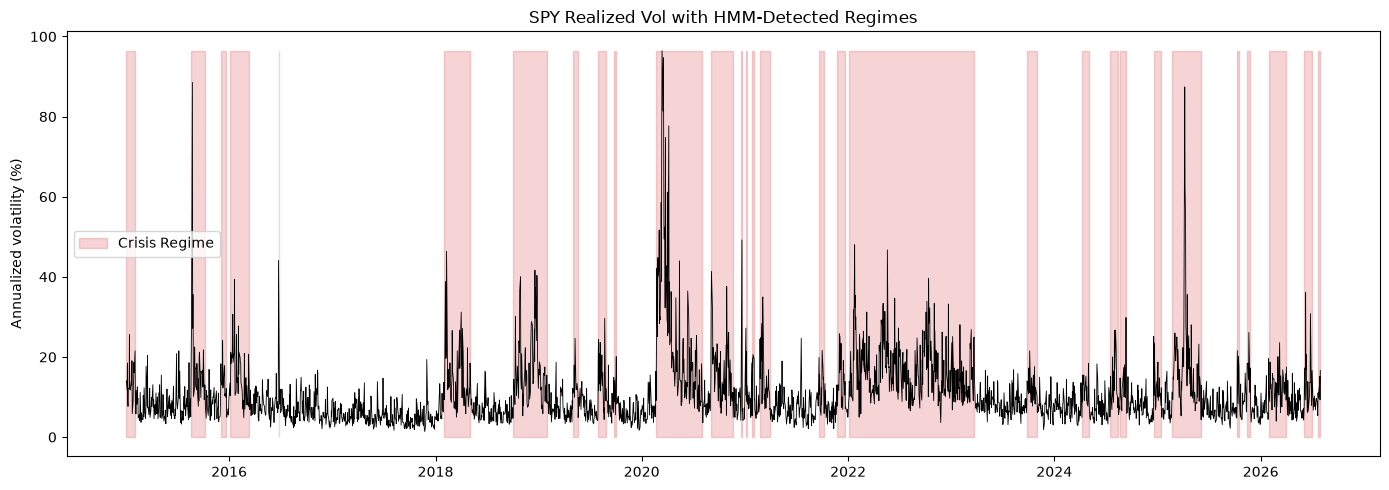

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rv.index, rv.values, color="black", lw=0.6)
ax.fill_between(
    rv.index, 0, rv.max(),
    where=(states2 == crisis_state), color="tab:red", alpha=0.2, label="Crisis Regime",
)
ax.set_title("SPY Realized Vol with HMM-Detected Regimes")
ax.set_ylabel("Annualized volatility (%)")
ax.legend()
plt.tight_layout()


Shading the realized-volatility series by the inferred regime confirms the model is picking up real events rather than noise: the crisis regime lands squarely on the 2015–16 China/oil selloff, the February and December 2018 spikes, the March 2020 COVID crash, the sustained 2022 selloff, and the 2025 tariff shock.

This two-state model is intuitive and already useful, but it imposes a strong assumption — that all elevated volatility belongs to a single "crisis" regime. That lumps together very different environments: a grinding, orderly selloff and an acute, disorderly crash are treated as the same state. The natural question is whether the data actually supports more than two regimes, and how many. Rather than choose by intuition, the next section selects the number of states formally, using an information criterion.

### How Many Regimes? Selecting the Number of States

Two states is a modeling choice, not a result. To select the number of regimes principledly, I fit models with $K = 2, \dots, 6$ states and compare them using the Bayesian Information Criterion (BIC):

$$
\text{BIC} = -2\,\ln \hat{L} + k \ln N
$$

where $\hat{L}$ is the fitted likelihood, $k$ the number of free parameters, and $N$ the sample size. BIC rewards fit (via the likelihood) but penalizes complexity (via $k \ln N$), so it only prefers a richer model when the improvement in fit outweighs the cost of the added parameters. Lower is better.

In [31]:
# Each candidate is fit from 25 random starts and the highest-likelihood
# solution kept -- see the note below on local optima.
selection = select_n_states(X, candidates=(2, 3, 4, 5, 6))
selection.round(1)


,logL,AIC,BIC,n_params
n_states,,,,
2,-1961.6,3937.2,3979.0,7
3,-1768.7,3565.4,3649.0,14
4,-1650.0,3345.9,3483.4,23
5,-1596.9,3261.8,3465.0,34
6,-1568.4,3230.8,3511.7,47


**A methodological note on fitting.** The Baum–Welch (EM) algorithm converges only to a *local* optimum, and its solution depends on the random initialization — a single fit per model is unreliable. Indeed, a naive one-shot fit produced a 3-state model no better than the 2-state one, a symptom of a bad local optimum. To fix this, each model is fit from 25 random starts and the highest-likelihood solution is kept (`fit_hmm` in `src/volforecast/regimes.py`). With this in place, the log-likelihood increases monotonically with $K$, as it must when the models are properly fit.

| States ($K$) | logL     | BIC     | ΔBIC vs. previous |
|:------------:|:--------:|:-------:|:-----------------:|
| 2            | −1961.6  | 3979.0  | —                 |
| 3            | −1768.7  | 3649.0  | −330.0            |
| 4            | −1650.0  | 3483.4  | −165.6            |
| 5            | −1596.9  | 3465.0  | −18.4             |
| 6            | −1568.4  | 3511.7  | +46.7             |

Read literally, BIC is minimized at $K = 5$. But taking the raw minimum would be a mistake here, for a reason specific to volatility data: realized volatility has a continuous, heavy right tail, so it is not truly generated by any finite number of Gaussian regimes. Additional states therefore keep shaving a little off BIC simply by carving the tail more finely, without necessarily identifying economically distinct regimes. The right question is not "where is the minimum" but "where do the returns to adding a state diminish" — i.e. where is the elbow.

That elbow is unambiguous. Adding the third state improves BIC by 330 and the fourth by a further 166 — large, meaningful gains. The fifth state buys only 18, and the sixth makes BIC *worse*. The value of additional structure effectively runs out after four states.

(Refitting this selection on the training window alone — the sample the forecasting model actually uses — makes the case cleaner still: there BIC is minimized outright at $K = 4$, with the fifth state making it worse. The elbow argument and the strict minimum agree.)

In [32]:
for n in (3, 4):
    m = fit_hmm(X, n_states=n, n_restarts=25)
    s = m.predict(X)
    print(f"\n{n}-state model:")
    for k in np.argsort(m.means_.ravel()):
        print(f"  mean vol {np.exp(m.means_[k, 0]):5.1f}%  |  {np.mean(s == k) * 100:4.1f}% of days")



3-state model:
  mean vol   5.5%  |  39.4% of days
  mean vol   9.7%  |  40.6% of days
  mean vol  18.7%  |  20.0% of days



4-state model:
  mean vol   4.9%  |  22.8% of days
  mean vol   7.8%  |  43.2% of days
  mean vol  14.1%  |  28.8% of days
  mean vol  28.8%  |   5.2% of days


**Interpretability confirms the choice.** Comparing the state compositions of the three- and four-state models:

| 3-state  |           | 4-state  |           |
|:--------:|:---------:|:--------:|:---------:|
| Mean vol | % of days | Mean vol | % of days |
| 5.5%     | 39.4%     | 4.9%     | 22.8%     |
| 9.7%     | 40.6%     | 7.8%     | 43.2%     |
| 18.7%    | 20.0%     | 14.1%    | 28.8%     |
|          |           | 28.8%    | 5.2%      |

The three-state model collapses all elevated volatility into a single 18.7% regime — it cannot distinguish a grinding, orderly selloff from an acute crash. The four-state model splits this into a *Stressed* regime (~14%) and a *Panic* regime (~29%), and crucially the extra Panic state is not a degenerate sliver fitting a handful of outliers: it occupies 5.2% of days (~150 observations), enough to be a genuine, learnable regime. The four-state model thus wins on both axes that matter — it sits at the BIC elbow *and* every one of its states is economically interpretable and well-populated.

I therefore proceed with **four regimes: Calm, Normal, Stressed, and Panic.**

### The Four Regimes

One structural point before the numbers. The model fit below uses the **full sample**, and it is used only to *describe* the historical record — the regime map and the stress index in this section. It is never used to produce a forecast. Every forecasting result later in the notebook comes from a separate model refit on the training window alone, because fitting an HMM on the full sample and then evaluating a regime-switching forecast out-of-sample would leak the test period into the transition matrix and the regime means.

In [33]:
# Descriptive model: fit on the full sample. This one is used only to describe
# the historical record (the regime map and the stress index below), never to
# produce a forecast -- the forecasting model is refit on the training window
# alone further down.
regimes_full = RegimeModel.fit(rv, n_states=4)

regime = regimes_full.hard_states(rv)
regimes_full.save("../models/hmm_4state.joblib")

pd.DataFrame({
    "mean_vol": regimes_full.mean_vols.round(2),
    "share_of_days": regime.value_counts(normalize=True).reindex(REGIME_LABELS).round(3),
    "expected_duration": regimes_full.expected_duration.round(1),
})


,mean_vol,share_of_days,expected_duration
Calm,4.88,0.229,13.0
Normal,7.84,0.435,11.0
Stressed,14.06,0.281,9.8
Panic,28.83,0.055,7.6


Converting each state's mean log-vol back to annualized volatility gives a clean severity ladder, with every regime occupying a meaningful share of the sample:

| Regime    | Mean annualized vol | Share of days | Expected duration | Character |
|-----------|:-------------------:|:-------------:|:-----------------:|-----------|
| Calm      | ~4.9%               | 22.9%         | 13 days           | Quiet, low-vol trending markets |
| Normal    | ~7.8%               | 43.5%         | 11 days           | The typical baseline state |
| Stressed  | ~14.1%              | 28.1%         | 10 days           | Elevated, orderly selloffs (e.g. much of 2022) |
| Panic     | ~28.8%              | 5.5%          | 8 days            | Acute dislocations (COVID, Dec 2018, 2025 tariffs) |

The decisive advantage of four states over a coarser model is the separation of *Stressed* from *Panic*. A two- or three-state model lumps all elevated volatility together, blurring the difference between a market that is merely nervous — grinding lower in an orderly way — and one that is genuinely dislocating. Here those are distinct regimes, at roughly 14% and 29% annualized vol respectively, and they differ in duration too: calm periods endure for weeks, acute crises burn out in about eight trading days.

### Transition Dynamics: An Ordered Ladder

In [34]:
regimes_full.transition_matrix.round(3)


,Calm,Normal,Stressed,Panic
Calm,0.923,0.075,0.002,0.000
Normal,0.042,0.909,0.049,0.000
Stressed,0.000,0.075,0.898,0.027
Panic,0.000,0.000,0.131,0.869


The labeled transition matrix (reordered by severity) reveals a strikingly clean structure:

| from \ to    | Calm  | Normal | Stressed | Panic |
|--------------|:-----:|:------:|:--------:|:-----:|
| **Calm**     | 0.923 | 0.075  | 0.002    | 0.000 |
| **Normal**   | 0.042 | 0.909  | 0.049    | 0.000 |
| **Stressed** | 0.000 | 0.075  | 0.898    | 0.027 |
| **Panic**    | 0.000 | 0.000  | 0.131    | 0.869 |

Two features stand out. First, every regime is highly persistent — the diagonal (0.87–0.92) dominates, the transition-matrix signature of volatility clustering. Expected durations, computed as $1/(1 - a_{ii})$, run from about 13 trading days for Calm down to roughly 8 for Panic: calm periods endure, while acute crises burn out relatively quickly.

Second, and more striking, the regimes behave as an **ordered ladder** — essentially all probability mass sits on the diagonal and its immediate neighbors. The market can only move one rung at a time. Calm transitions to Normal but essentially never jumps straight to Stressed or Panic ($\approx 0$); Panic can only be *reached* from Stressed and can only *exit* back to Stressed — it never connects directly to Calm or Normal. Escalation therefore always follows Calm → Normal → Stressed → Panic, and de-escalation retraces the same steps in reverse.

This has a genuinely useful implication: **acute panic is always preceded, and followed, by a Stressed phase.** Crises do not erupt out of quiet markets without warning, nor do they resolve by snapping instantly back to calm — they climb and unwind through the intermediate rung. That is precisely the property an early-warning indicator needs: the Stressed regime acts as an antechamber to Panic, giving the model a chance to flag rising danger before volatility fully peaks.

### The Early-Warning Stress Index

Collapsing the per-day regime probabilities into a single severity-weighted score (Calm = 0, Normal = ⅓, Stressed = ⅔, Panic = 1) yields a continuous **stress index** on $[0, 1]$ — a smooth, interpretable read on where the market sits on the calm-to-panic spectrum each day.

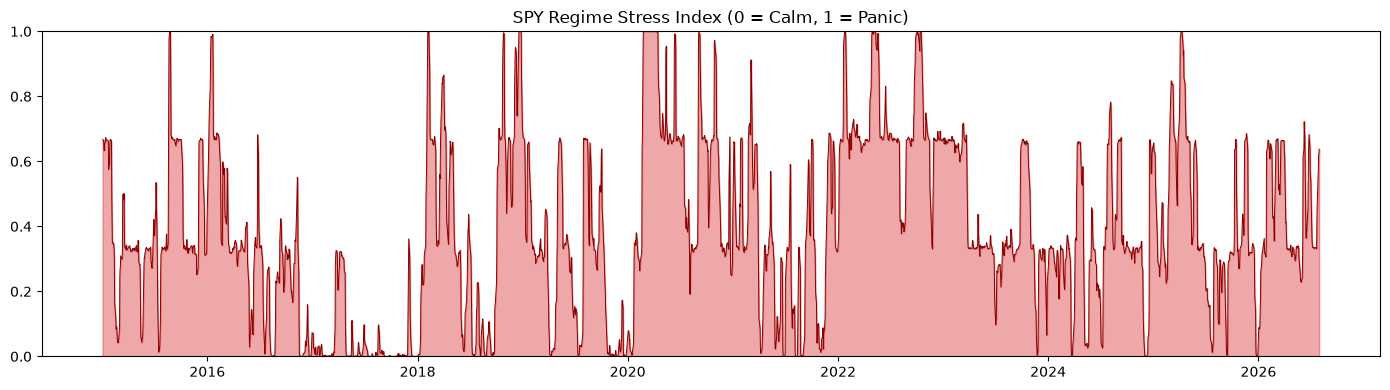

In [35]:
smoothed = regimes_full.smoothed_probs(rv)
stress_index = regimes_full.stress_index(smoothed)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(stress_index.index, 0, stress_index.values, color="tab:red", alpha=0.4)
ax.plot(stress_index.index, stress_index.values, color="darkred", lw=0.7)
ax.set_title("SPY Regime Stress Index (0 = Calm, 1 = Panic)")
ax.set_ylim(0, 1)
plt.tight_layout()


Plotted over the full sample, the index behaves exactly as an early-warning indicator should. It sits near zero through genuinely quiet stretches such as 2017 and mid-2024; it forms a sustained *plateau* around 0.6 during 2022, correctly reading that year as a prolonged Stressed grind rather than an acute crisis; and it pegs at its 1.0 ceiling only during true dislocations — the March 2020 COVID crash and the 2025 tariff selloff — with sharp intermediate spikes at the 2015–16 selloff and the February and December 2018 episodes.

The key visual takeaway is that the index captures the *level* of stress, not merely its presence. The 2022 plateau and the 2020/2025 peaks are clearly different heights, reflecting the Stressed-versus-Panic distinction that the four-state model was chosen to capture. And because the underlying regime chain is an ordered ladder, the index rises and falls through the intermediate range rather than jumping discontinuously between calm and crisis — it ramps into turmoil and decays out of it, which is what makes it usable as a forward-looking signal rather than a coincident one.

## A Regime-Switching HAR

The regime detector establishes that the market moves between distinct volatility states; the natural next step is to let the *forecasting model* itself change with the regime. A single-regime HAR imposes one fixed relationship between lagged and current volatility across all market conditions — but the coefficient analysis below shows those dynamics differ sharply by regime, which means a single specification is misspecified. A regime-switching HAR relaxes this by allowing the HAR coefficients (and baseline level) to depend on the prevailing regime.

There are two ways to build such a model. The first, *joint estimation* (e.g. `statsmodels` `MarkovRegression`), treats the regime as a latent variable and estimates the hidden Markov chain and the regime-specific regression coefficients simultaneously in a single model — the textbook Markov-switching regression. The second, which this project adopts, is a *two-step, regime-conditional* approach: the regimes are first identified by the hidden Markov model of the previous section, and a separate HAR is then estimated within each regime.

The two-step approach is chosen deliberately. Because the HMM regimes have already been fit, validated, and interpreted — with a clear economic reading and a well-behaved transition structure — conditioning on them keeps a single, consistent regime definition running through the entire project, rather than introducing a second, separately-estimated set of latent states that may or may not align with the first. It also makes the out-of-sample forecasting fully transparent: each step, from regime probabilities to the final probability-weighted forecast, is explicit and controllable, rather than delegated to the internal machinery of a joint model whose four-regime likelihood is difficult to optimize and to forecast from reliably. The trade-off is that this is technically a regime-*conditional* HAR rather than a jointly-estimated Markov-switching HAR; the joint model is noted as a possible robustness check, but the two-step approach is both more coherent with the rest of the pipeline and more tractable to forecast with.

### Regime-Specific HAR Coefficients

From here on, everything is a forecasting exercise, so the regime model is **refit on the training window alone** (2015–2022). Nothing after the split date touches the transition matrix, the regime means, or the regime-specific regression coefficients. The full-sample model from the previous section stays where it belongs: describing history.

One consequence worth noting up front — the training window is a more volatile sample than the full history (it contains COVID), so the train-only regime thresholds sit slightly higher than the descriptive ones above: Calm 5.0%, Normal 8.3%, Stressed 15.2%, Panic 31.0%.

In [36]:
from volforecast.ms_har import MSHAR, diebold_mariano, qlike, qlike_loss

# Everything from here on is a forecasting exercise, so the regime model is
# refit on the training window alone. Nothing after SPLIT_DATE touches the
# transition matrix or the regime means.
rv_train = rv[rv.index < SPLIT_DATE]
regimes_train = RegimeModel.fit(rv_train, n_states=4)

train_labels = regimes_train.hard_states(rv_train)
ms_har = MSHAR.fit(train_har, train_labels)

print("Training days per regime:", ms_har.n_obs.to_dict())
print("\nRegime mean vols:", regimes_train.mean_vols.round(2).to_dict())


Training days per regime: {'Calm': 638, 'Normal': 725, 'Stressed': 503, 'Panic': 126}

Regime mean vols: {'Calm': 4.98, 'Normal': 8.33, 'Stressed': 15.19, 'Panic': 31.01}


In [37]:
coef_table = ms_har.coefs.round(3)
coef_table


,Calm,Normal,Stressed,Panic
const,4.526,8.625,14.539,18.976
rv_lag1,0.064,0.052,0.065,0.139
rv_lag5,-0.035,-0.024,-0.017,0.513
rv_lag22,0.094,0.000,0.048,-0.147


Fitting a separate HAR regression within each HMM-detected regime (training period only) yields markedly different dynamics across states:

| Coefficient | Calm  | Normal | Stressed | Panic  |
|-------------|:-----:|:------:|:--------:|:------:|
| **const**   | 4.526 | 8.625  | 14.539   | 18.976 |
| rv_lag1     | 0.064 | 0.052  | 0.065    | 0.139  |
| rv_lag5     | −0.035| −0.024 | −0.017   | 0.513  |
| rv_lag22    | 0.094 | 0.000  | 0.048    | −0.147 |

Two patterns stand out. First, the **intercept rises monotonically** across regimes (4.5 → 8.6 → 14.5 → 19.0): each regime mean-reverts to a progressively higher baseline level of volatility.

Second, and more revealing, the **autoregressive structure switches on only in Panic.** In the Calm, Normal, and Stressed regimes the lag coefficients are small — within these states, volatility simply reverts toward its regime baseline with little momentum. Only in the Panic regime do the lags carry real weight (rv_lag1 = 0.14, rv_lag5 = 0.51, combined persistence ≈ 0.65): volatility becomes genuinely self-reinforcing, feeding on its own recent values. This is the mechanical signature of a crisis feedback loop, and it distinguishes Panic from Stressed on *dynamics* rather than level alone.

This also reinterprets the single-regime HAR. The pooled model estimated high persistence (rv_lag1 + rv_lag5 ≈ 0.81), yet within-regime persistence is near-zero outside of Panic. The reconciliation is that the pooled model's apparent persistence is largely a *between-regime* effect: lagged volatility predicts current volatility mostly because the market tends to remain in the same regime — and hence at the same level — from one day to the next. Once the regime baseline is absorbed into a switching intercept, little within-regime autoregression remains except during panics. The single-regime HAR thus conflates two distinct mechanisms — "volatility is high because we are in a high-volatility regime" and "volatility is high because it was high yesterday" — that the regime-switching specification separates.

A caveat on the Panic column: it is estimated from only 126 training days, so its coefficients are the least precisely identified in the table.

### Causal Regime Probabilities for Forecasting

Generating honest out-of-sample forecasts requires the regime probabilities used on each test day to depend only on information available *before* that day. Two distinct issues have to be handled, and it is easy to fix one and miss the other.

**The smoothing problem.** The probabilities used earlier for the descriptive stress index are *smoothed* — $P(\text{regime}_t \mid \text{the entire sample})$ — so they condition on the future. The forecast instead uses *filtered* probabilities, $P(\text{regime}_t \mid \text{data through } t)$, computed by a forward recursion, then propagated one step through the transition matrix to give $P(\text{regime}_{t+1} \mid \text{data through } t)$.

**The alignment problem.** Those one-step-ahead probabilities must then be lined up with the right rows of the design matrix. The array is naturally indexed by the day the belief was *formed*, but the HAR design matrix row for day $d$ targets day $d$'s realized volatility — so joining them directly would use information through day $d$ to forecast day $d$. In this implementation `predicted_probs` returns a frame indexed by the day being *forecast*, which makes the join correct by construction rather than by remembering to shift.

In [38]:
# Filtered probabilities: P(regime today | data through today). Propagated one
# step through the transition matrix, they give P(regime tomorrow | data
# through today) -- indexed by the day being forecast, so aligning them with
# the HAR design matrix is causally correct by construction.
predicted_probs = regimes_train.predicted_probs(rv)

test_dates = test_har.index.intersection(predicted_probs.index)
filt_probs = predicted_probs.loc[test_dates]
filt_probs.head().round(3)


,Calm,Normal,Stressed,Panic
Date,,,,
2023-01-03,0.007,0.193,0.775,0.025
2023-01-04,0.001,0.076,0.858,0.066
2023-01-05,0.001,0.081,0.873,0.046
2023-01-06,0.030,0.548,0.406,0.016
2023-01-09,0.002,0.090,0.819,0.089


In [39]:
print("Highest Panic-probability day:", filt_probs["Panic"].idxmax().date())
print("Highest Calm-probability day: ", filt_probs["Calm"].idxmax().date())


Highest Panic-probability day: 2025-04-09
Highest Calm-probability day:  2025-09-16


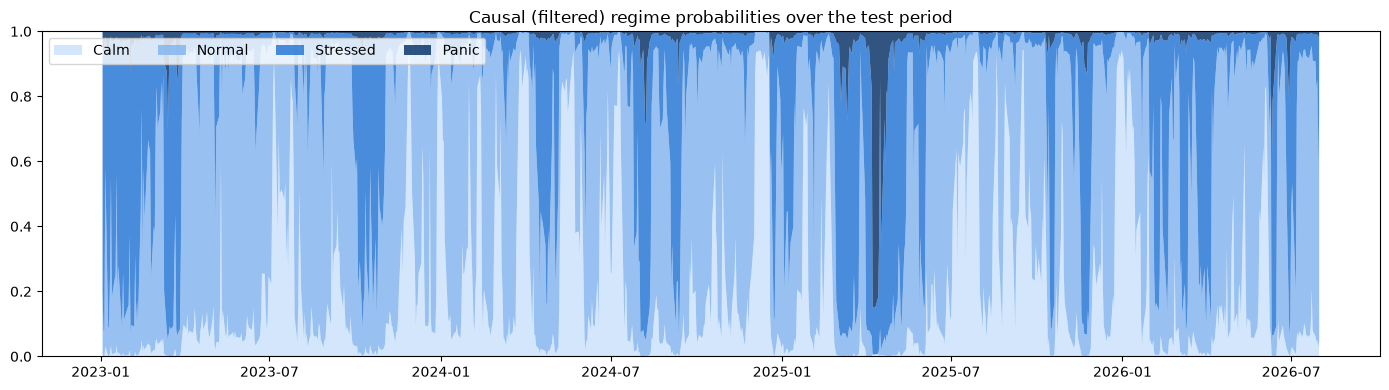

In [40]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(
    filt_probs.index, filt_probs.T.values,
    labels=list(REGIME_LABELS), alpha=0.85,
    colors=["#cde2fb", "#86b6ef", "#2a78d6", "#0d366b"],
)
ax.set_title("Causal (filtered) regime probabilities over the test period")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", ncols=4)
plt.tight_layout()


The probabilities are returned in severity order (Calm, Normal, Stressed, Panic) and validate against known events: the highest Panic probability in the test period falls on 9 April 2025 — the peak of the tariff-driven selloff — and the highest Calm probability on a quiet day in September 2025, confirming the state labelling is correct.

The stacked plot shows the model spending most of the test period in Normal with intermittent excursions into Stressed, and a single sharp, unambiguous Panic episode in April 2025.

### Out-of-Sample Forecast Comparison

In [41]:
ms_forecast = ms_har.forecast(test_har, predicted_probs)
y_true = test_har.loc[ms_forecast.index, "rv"]

rmse_ms = rmse(y_true, ms_forecast)
print(f"MS-HAR test RMSE: {rmse_ms:.2f}")


MS-HAR test RMSE: 5.03


In [42]:
single_pred = har_predict(har_model_train, test_har).loc[ms_forecast.index]

rmse_single = rmse(y_true, single_pred)
print(f"Single-regime HAR test RMSE: {rmse_single:.2f}")


Single-regime HAR test RMSE: 4.88


In [43]:
print(f"MS-HAR QLIKE:        {qlike(y_true, ms_forecast):.4f}")
print(f"Single-regime QLIKE: {qlike(y_true, single_pred):.4f}")


MS-HAR QLIKE:        0.3682
Single-regime QLIKE: 0.3588


Each MS-HAR forecast is a probability-weighted blend of the four regime-specific predictions, weighted by the model's one-step-ahead regime probabilities. Against the single-regime HAR on identical test dates (2023 onward, 897 days):

| Model             | RMSE | QLIKE  |
|-------------------|:----:|:------:|
| Single-regime HAR | 4.88 | 0.3588 |
| MS-HAR (regime)   | 5.03 | 0.3682 |

The single-regime HAR is slightly better on **both** metrics — symmetric RMSE and the asymmetric QLIKE that volatility forecasting usually prefers. The gap is small, and the next section tests whether it is distinguishable from noise at all, but the direction is worth stating plainly: adding regime structure did not improve the point forecast, it marginally degraded it.

The mechanism is visible in the coefficient table. Within Calm, Normal and Stressed, the regime-specific regressions are nearly pure intercepts — they predict close to the regime's mean level and ignore the lags. That is a *coarser* use of the information than the pooled HAR, which reads the lags directly and can place a forecast anywhere on a continuum rather than near one of four levels. The regime model wins only when the level itself shifts abruptly; it loses ground on the many ordinary days when the pooled model's lags already carry the answer.

### Is the Difference Significant? A Diebold–Mariano Test

A difference in average QLIKE is only meaningful if it is distinguishable from noise. The Diebold–Mariano test evaluates this formally by testing whether the mean of the per-day QLIKE loss differential is significantly different from zero, using the Harvey–Leybourne–Newbold small-sample correction. The statistic is signed so that a **positive** value means the second model has the lower loss.

In [44]:
loss_single = qlike_loss(y_true, single_pred)
loss_ms = qlike_loss(y_true, ms_forecast)

# A positive statistic means the SECOND argument has the lower average loss.
dm_stat, p_val = diebold_mariano(loss_single, loss_ms)
print(f"DM statistic: {dm_stat:.3f}   p-value: {p_val:.4f}")


DM statistic: -1.083   p-value: 0.2790


In [45]:
d = pd.Series(loss_single - loss_ms, index=y_true.index)
print("Test days where MS-HAR helps most:")
print(d.nlargest(5).round(3))
print("\nTest days where MS-HAR hurts most:")
print(d.nsmallest(5).round(3))


Test days where MS-HAR helps most:
Date
2026-06-09    1.867
2024-09-11    1.428
2023-02-01    1.238
2026-04-23    1.012
2023-01-03    0.810
dtype: float64

Test days where MS-HAR hurts most:
Date
2025-04-07   -5.515
2024-05-31   -1.197
2025-04-16   -1.025
2026-06-05   -0.895
2024-04-04   -0.895
dtype: float64


The test returns **DM = −1.08, p = 0.28**. The negative sign reflects the single-regime model's lower average QLIKE, but the p-value is far from significant: on point-forecast accuracy the two models are **statistically indistinguishable**. The honest summary is that regime-switching bought nothing here — not that it actively hurt.

This is consistent with the literature rather than a shortcoming of the model — Ding et al. (2025) similarly find that the out-of-sample benefit of regime-switching for realised volatility is "less clear-cut at the daily horizon."

Inspecting *where* each model wins is more informative than the average. The days where MS-HAR helps most are scattered, isolated volatility spikes — abrupt jumps the pooled model's lags have not yet absorbed. The day where it hurts most is dramatic and singular: **7 April 2025**, at the onset of the tariff crash, costs it −5.5 in QLIKE, larger than its five best days combined. That single day is the story of the whole comparison. At the start of an acute dislocation the regime filter is still assigning most of its probability to Stressed rather than Panic — it has only seen one day of the shock — so the blended forecast lands well below the volatility that actually materialized. The regime label arrives *with* the crisis, not before it.

This is the fundamental limitation of a filter that observes only realized volatility: it can identify a regime shift about as fast as the volatility itself moves, which is to say not fast enough to help on the first day. It is also precisely the case a richer feature set — cross-asset correlations, credit spreads, options-implied skew — would be expected to improve, and a natural direction for future work.

The broader implication is methodological: point-forecast accuracy is not the right lens for a regime-switching model. Its distinctive contribution is not a sharper central forecast but a better-calibrated *conditional distribution* — wider and fatter-tailed when crisis probability rises — which average point-error metrics cannot detect by construction. The remaining sections therefore evaluate the predictive distribution directly, through Monte Carlo simulation and tail-risk backtesting.

## Probabilistic Forecasting via Monte Carlo

The forecasts so far have been single numbers, but a point forecast throws away what the regime model uniquely knows: the *shape* of the distribution of future volatility, which depends on the current market state. This section recovers that full distribution by simulation.

The idea is to generate many possible futures. Each simulated path starts by sampling the current regime from the model's filtered probabilities, then walks forward one day at a time — transitioning between regimes according to the estimated Markov chain, drawing that regime's HAR prediction, and adding that regime's characteristic noise, feeding each new value back into the lag structure. Running thousands of these paths and reading percentiles at each horizon produces a predictive distribution rather than a single line: a *fan chart*.

### Building the Simulator

Two ingredients drive the simulation beyond the regime coefficients already estimated: the transition matrix (how regimes evolve) and each regime's residual standard deviation (how much noise to add within a regime). The residual stds climb steeply with severity — 2.0, 3.1, 5.1 and 14.0 across Calm, Normal, Stressed and Panic — so a path that wanders into a high-volatility regime carries not just a higher level but far greater dispersion. That near-sevenfold spread between Calm and Panic is what makes the simulated distribution genuinely regime-dependent rather than a rescaled version of the same shape.

In [46]:
from volforecast.simulate import path_quantiles, simulate_paths

A = regimes_train.transition_matrix.values   # (4, 4), severity order
B = ms_har.coefs.values                       # (4 coefs, 4 regimes)
resid_std = ms_har.resid_std.values           # within-regime noise

print("Residual std per regime:", ms_har.resid_std.round(2).to_dict())


Residual std per regime: {'Calm': 2.04, 'Normal': 3.14, 'Stressed': 5.13, 'Panic': 14.0}


In [47]:
def simulate_from(as_of, horizon=10, n_paths=3000, seed=0):
    """Simulate volatility paths launched from a given date."""
    history = rv.loc[:as_of]
    pi0 = regimes_train.filtered_probs(history).iloc[-1].values
    return simulate_paths(
        rv_history=history.values, pi0=pi0, transmat=A, coefs=B,
        resid_std=resid_std, horizon=horizon, n_paths=n_paths, seed=seed,
    )


### The Predictive Distribution

The simulation is launched from the last day of the sample, 31 July 2026 — which, with realized volatility at 16.7%, the filter reads as **Stressed**.

Launched from 2026-07-31 (RV 16.7%), most likely regime: Stressed (69%)


,p5,p25,p50,p75,p95
days_ahead,,,,,
1,5.2,9.5,13.5,17.9,24.6
2,4.6,9.1,12.9,17.8,24.7
3,4.3,8.5,12.6,17.8,25.9
4,4.4,8.6,12.3,17.5,26.9
5,4.4,8.3,12.2,17.5,27.6
6,3.9,8.0,12.1,17.6,28.6
7,4.1,7.8,11.9,17.4,30.1
8,3.9,7.7,11.8,17.2,30.8
9,3.7,7.6,11.5,16.9,31.6


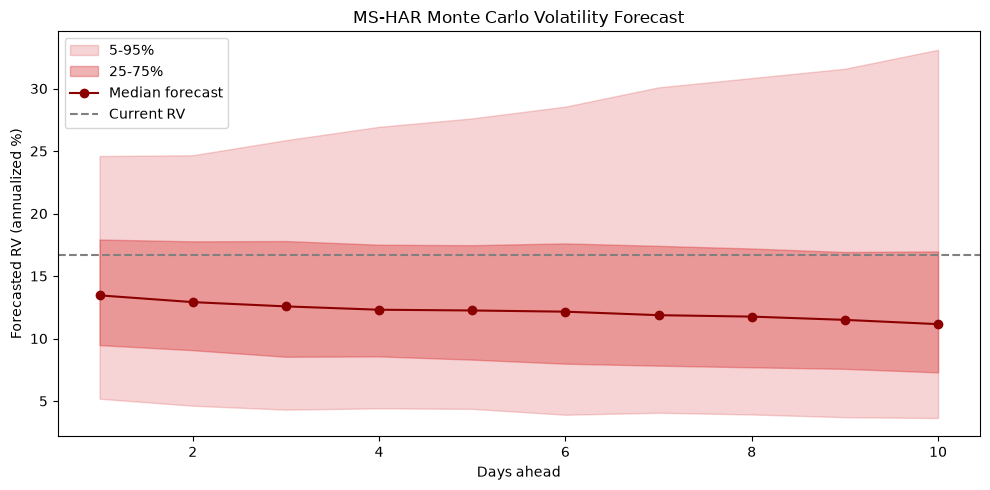

In [48]:
H = 10
as_of = rv.index[-1]
paths = simulate_from(as_of, horizon=H)
fan = path_quantiles(paths)
x = fan.index.values

launch_regime = regimes_train.filtered_probs(rv.loc[:as_of]).iloc[-1]
print(f"Launched from {as_of.date()} (RV {rv.iloc[-1]:.1f}%), "
      f"most likely regime: {launch_regime.idxmax()} ({launch_regime.max():.0%})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x, fan["p5"], fan["p95"], alpha=0.20, color="tab:red", label="5-95%")
ax.fill_between(x, fan["p25"], fan["p75"], alpha=0.35, color="tab:red", label="25-75%")
ax.plot(x, fan["p50"], color="darkred", marker="o", label="Median forecast")
ax.axhline(rv.iloc[-1], ls="--", color="gray", label="Current RV")

ax.set_xlabel("Days ahead")
ax.set_ylabel("Forecasted RV (annualized %)")
ax.set_title("MS-HAR Monte Carlo Volatility Forecast")
ax.legend()
plt.tight_layout()

fan.round(1)


Launched from a stressed day, the fan chart shows two features a single-regime model cannot produce.

The median forecast mean-reverts *downward*, from the current 16.7% toward roughly 11% over ten days — the model expects the stress to decay, but gradually, because the transition matrix says Stressed is a persistent state that unwinds through Normal rather than snapping back to Calm.

More importantly, the distribution is strongly **right-skewed**, and the skew widens with horizon. At one day ahead the 5–95% band spans roughly 5–25%; by day ten the median has fallen to 11% while the 95th percentile has *risen* to 33%. The upper tail grows even as the centre declines, because a minority of simulated paths escalate from Stressed into Panic and then feed on themselves through the Panic regime's high autoregressive coefficients. The lower band, meanwhile, is anchored by the Calm floor. A single-regime Gaussian model produces a symmetric cone by construction and would report a tightening band around a falling median — exactly backwards for the risk that matters.

### Regime-Dependent Uncertainty

In [49]:
# Launch one cone from the calmest day in the test period and one from the most
# stressed, so the contrast isolates the regime rather than the calendar.
stress_test = regimes_train.stress_index(filt_probs)
t0_calm, t0_stress = stress_test.idxmin(), stress_test.idxmax()

print(f"Calm cone     from {t0_calm.date()}  (RV {rv.loc[t0_calm]:5.1f}%, stress {stress_test.min():.2f})")
print(f"Stressed cone from {t0_stress.date()}  (RV {rv.loc[t0_stress]:5.1f}%, stress {stress_test.max():.2f})")

paths_calm = simulate_from(t0_calm, horizon=10)
paths_stress = simulate_from(t0_stress, horizon=10)


Calm cone     from 2025-09-16  (RV   3.8%, stress 0.02)
Stressed cone from 2025-04-09  (RV  58.6%, stress 0.95)


Calm launch                      Panic launch                        
                    p5  p25  p50  p75   p95           p5   p25   p50   p75   p95
days_ahead                                                                      
1                  2.0  4.0  5.4  6.8   9.4         15.8  33.2  46.7  57.4  72.1
2                  2.1  4.1  5.6  7.1  10.0         10.4  22.0  44.3  57.5  72.9
3                  2.0  4.1  5.7  7.4  11.1          8.3  18.0  41.0  57.7  75.4
4                  2.2  4.3  5.8  7.5  11.7          7.6  16.1  30.3  51.4  70.8
5                  2.2  4.3  5.9  7.8  12.3          6.9  14.6  23.2  47.7  67.2
6                  2.2  4.3  5.9  7.9  13.2          6.0  13.4  20.3  42.8  65.6
7                  2.1  4.3  6.1  8.3  13.4          5.9  12.3  18.9  37.6  62.0
8                  2.2  4.5  6.1  8.3  14.8          6.0  11.7  17.9  32.5  60.0
9                  2.2  4.4  6.2  8.6  14.9          5.6  10.7  17.1  27.8  57.1
10                 2.0  4.5  6.3  8.7  15.9          5.1  10.4  16.3  24.8  54.2

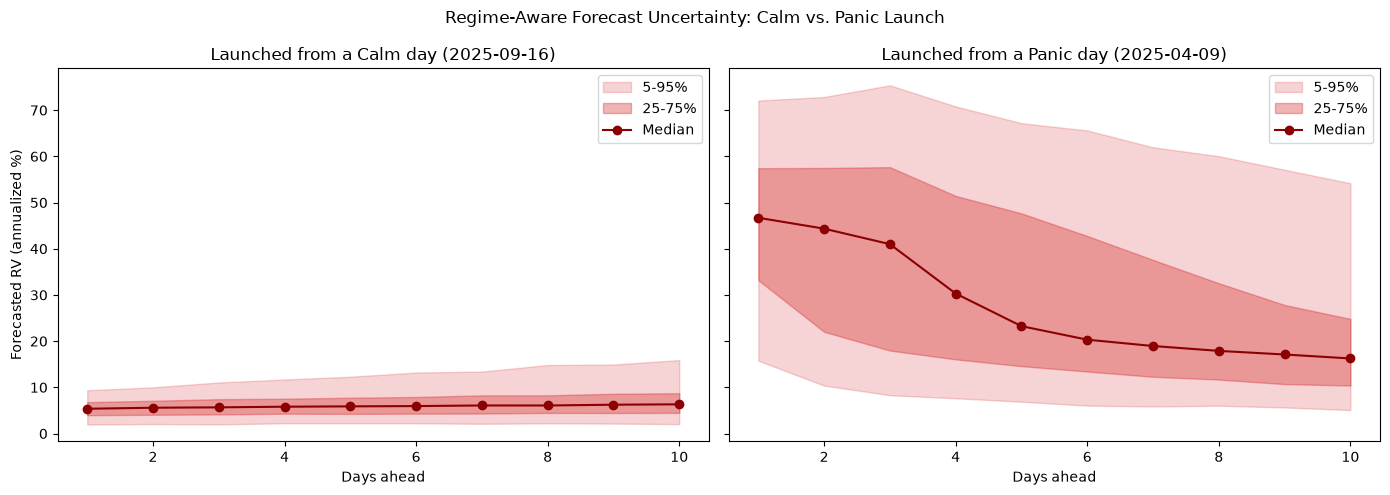

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

panels = [
    (axes[0], paths_calm, f"Launched from a Calm day ({t0_calm.date()})"),
    (axes[1], paths_stress, f"Launched from a Panic day ({t0_stress.date()})"),
]

for ax, p, title in panels:
    f = path_quantiles(p)
    x = f.index.values
    ax.fill_between(x, f["p5"], f["p95"], alpha=0.20, color="tab:red", label="5-95%")
    ax.fill_between(x, f["p25"], f["p75"], alpha=0.35, color="tab:red", label="25-75%")
    ax.plot(x, f["p50"], color="darkred", marker="o", label="Median")
    ax.set_title(title)
    ax.set_xlabel("Days ahead")
    ax.legend()

axes[0].set_ylabel("Forecasted RV (annualized %)")
plt.suptitle("Regime-Aware Forecast Uncertainty: Calm vs. Panic Launch")
plt.tight_layout()

pd.concat({"Calm launch": path_quantiles(paths_calm).round(1),
           "Panic launch": path_quantiles(paths_stress).round(1)}, axis=1)


The most important property of the model is that its forecast *uncertainty* is not fixed — it depends on the regime it is launched from. The two panels above show forecasts from the same model on the two extremes of the test period: 16 September 2025, the calmest day (realized vol 3.8%, stress index 0.02), and 9 April 2025, the peak of the tariff crisis (realized vol 58.6%, stress index 0.95).

The contrast is stark, and it is a contrast in *shape*, not just level:

| Launched from | Day-1 median | Day-1 5–95% band | Day-10 median | Day-10 5–95% band |
|---------------|:------------:|:----------------:|:-------------:|:-----------------:|
| Calm day      | 5.4%         | 2.0 – 9.4%       | 6.3%          | 2.0 – 15.9%       |
| Panic day     | 46.7%        | 15.8 – 72.1%     | 16.3%         | 5.1 – 54.2%       |

The calm cone is low and tight — a 7-point band at one day out, widening only gradually as paths accumulate a small chance of escalating. The panic cone opens at a 56-point band, more than eight times wider, and its median decays from 46.7% to 16.3% over ten days without ever fully reverting — a market in crisis unwinds through Stressed and Normal rather than snapping straight back to Calm. Even at day ten its 95th percentile (54.2%) sits above where the calm cone's *entire* distribution lies.

This is the substantive contribution of the regime-switching framework. It does not merely shift the central forecast up during turmoil; it widens the entire distribution, because the range of plausible near-term outcomes genuinely is far larger in a crisis than in a calm market. A model that reports the same uncertainty band in both environments — as any single-regime model must — misrepresents risk in precisely the situations where getting risk right matters most. Quantifying that regime-dependent uncertainty is exactly what the tail-risk evaluation of the next section measures.

## Risk-Management Evaluation

A volatility forecast is ultimately an input to risk management, where what matters is not the average day but the worst ones — the 1-in-100 losses that size capital buffers and margin. This section evaluates the models the way a risk desk would: through Value-at-Risk (VaR) and Expected Shortfall (ES), backtested for calibration.

The key modelling choice is the assumed shape of the return tail. Crisis losses are, by nature, rare and extreme — precisely the region where a Gaussian assumption fits worst, systematically understating how far the tail extends. Rather than assume a distribution for the whole return and hope it fits the tail, this analysis models the tail directly using **Extreme Value Theory (EVT)**. The Pickands–Balkema–de Haan theorem establishes that exceedances over a sufficiently high threshold converge to a **Generalized Pareto Distribution (GPD)** regardless of the underlying distribution, making it the theoretically grounded choice for extreme quantiles. The overall approach follows McNeil & Frey (2000): a conditional volatility model paired with a GPD tail fit to the standardized residuals.

### Step 1: Volatility Forecasts

Conditional EVT begins from a volatility forecast — the tail is modelled on returns *standardized* by that forecast, so the first step is to assemble each model's one-day volatility forecast. Both are needed in two windows: in-sample (training) forecasts, used to fit the tail, and out-of-sample (test) forecasts, used to apply it.

One methodological point matters here. Each model must be standardized on the training side by the *same kind* of forecast it will be scored with on the test side. For the single-regime HAR that is trivially true. For MS-HAR it is not automatic: it is tempting to build the training forecast from each day's hard-assigned regime, since the labels are known in sample. But the test forecast is a probability-weighted blend across all four regimes, and a blend is a smoother, less extreme object than a hard assignment. Fitting the tail on hard assignments and applying it to blends fits the tail to the wrong distribution — it makes the standardized training residuals look thinner than the ones the model will actually produce, and the resulting risk measures come out too optimistic. Both windows below therefore use the probability-weighted forecast.

In [51]:
from volforecast.data import to_daily_sigma
from volforecast.evt import backtest_table, backtest_var, fit_gpd_tail

# Both models are standardized the same way on both sides of the split: the
# training tail is fit on the same kind of forecast the test period is scored
# with (probability-weighted for MS-HAR, not a hard regime assignment).
train_dates = train_har.index.intersection(returns.index).intersection(predicted_probs.index)

fc_single_train = har_predict(har_model_train, train_har.loc[train_dates])
fc_ms_train = ms_har.forecast(train_har.loc[train_dates], predicted_probs)

fc_single_test = single_pred
fc_ms_test = ms_forecast

sig_single_train, sig_single_test = to_daily_sigma(fc_single_train), to_daily_sigma(fc_single_test)
sig_ms_train, sig_ms_test = to_daily_sigma(fc_ms_train), to_daily_sigma(fc_ms_test)

print(f"Train days: {len(train_dates):,} | Test days: {len(fc_ms_test):,}")
print(f"Mean daily vol (test) -- single: {sig_single_test.mean():.4f}  MS: {sig_ms_test.mean():.4f}")


Train days: 1,992 | Test days: 897
Mean daily vol (test) -- single: 0.0064  MS: 0.0065


The two models produce nearly identical *average* daily volatility on the test set (0.64% and 0.65%). This is expected — they differ not in their central level but in how they distribute volatility across regimes, which is what the tail analysis will probe.

### Step 2: Fitting the GPD Tail

Each model's returns are standardized by its volatility forecast, $z_t = r_t / \hat{\sigma}_t$, which removes the time-varying volatility and leaves residuals with a stable tail shape. A peaks-over-threshold GPD is fit to the exceedances of the standardized *losses* over a high threshold $u$ (the 90th percentile, giving 200 exceedances):

$$
P(L - u \le y \mid L > u) \approx G_{\xi,\beta}(y) = 1 - \left(1 + \frac{\xi y}{\beta}\right)^{-1/\xi}
$$

with shape $\xi$ (tail heaviness) and scale $\beta$. From the fit, the standardized VaR and ES at confidence $p$ follow in closed form:

$$
\mathrm{VaR}_p = u + \frac{\beta}{\xi}\left[\left(\tfrac{N}{N_u}(1-p)\right)^{-\xi} - 1\right], \qquad
\mathrm{ES}_p = \frac{\mathrm{VaR}_p}{1-\xi} + \frac{\beta - \xi u}{1-\xi}
$$

These are multipliers on the standardized scale; the day-$t$ risk measures are recovered by scaling with the volatility forecast, $\mathrm{VaR}_{p,t} = \hat{\sigma}_t \cdot \mathrm{VaR}_p$.

In [52]:
z_single_train = returns.loc[train_dates].values / sig_single_train.values
z_ms_train = returns.loc[fc_ms_train.index].values / sig_ms_train.values

tail_single = fit_gpd_tail(z_single_train)
tail_ms = fit_gpd_tail(z_ms_train)

pd.DataFrame({
    "xi (shape)": [tail_single.xi, tail_ms.xi],
    "beta (scale)": [tail_single.beta, tail_ms.beta],
    "threshold": [tail_single.threshold, tail_ms.threshold],
    "exceedances": [tail_single.n_exceed, tail_ms.n_exceed],
    "99% multiplier": [tail_single.var(0.99), tail_ms.var(0.99)],
}, index=["Single-regime", "MS-HAR"]).round(3)


,xi (shape),beta (scale),threshold,exceedances,99% multiplier
Single-regime,0.128,0.862,1.677,200,3.989
MS-HAR,0.054,0.968,1.629,200,4.009


| Model         | ξ (shape) | β (scale) | Threshold | Exceedances | 99% multiplier |
|---------------|:---------:|:---------:|:---------:|:-----------:|:--------------:|
| Single-regime | 0.128     | 0.862     | 1.68      | 200         | 3.99           |
| MS-HAR        | 0.054     | 0.968     | 1.63      | 200         | 4.01           |

Two observations. First, both 99% multipliers are almost exactly 4.0 — far above the Gaussian value of 2.33 — quantifying directly how severely a normal assumption understates the tail. Both shape parameters lie well below 0.5 (finite variance) and 1 (finite ES), so the risk measures are well-defined.

Second, the two models reach nearly the same multiplier by different routes. The single-regime residuals keep a heavier tail (ξ = 0.128) with a smaller scale; the MS-HAR residuals are closer to exponential (ξ = 0.054) with a larger scale (β = 0.97 vs 0.86). Its regime-conditional volatility — via the Panic regime — rises to meet extreme days and absorbs some of the tail heaviness, leaving residuals whose extremity is carried by scale rather than by shape. With 200 exceedances each shape estimate carries a standard error near ±0.08, so the difference in ξ is directional evidence, not a hard claim; the near-identical VaR multipliers are the more robust finding.

### Step 3: VaR and ES Backtest

The fitted tails are now turned into daily VaR and ES on the test set and backtested. Two coverage tests assess VaR: **Kupiec** checks whether the violation *rate* matches the target (unconditional coverage), and **Christoffersen** additionally checks whether violations *cluster* in time (conditional coverage) — a good VaR model's breaches should be independent, not bunched. For ES, the model's predicted average breach loss is compared against the realized average loss on breach days; a well-calibrated ES has the two roughly equal.

In [53]:
r_test = returns.loc[ms_forecast.index].values

rows = []
for level in (0.99, 0.95):
    rows.append(backtest_var(r_test, sig_single_test.values, tail_single, level, "Single-regime HAR"))
    rows.append(backtest_var(r_test, sig_ms_test.values, tail_ms, level, "MS-HAR"))

backtest = backtest_table(rows)
backtest[["model", "level", "violations", "expected", "rate",
          "kupiec_p", "christoffersen_p", "predicted_es", "realized_es"]]


,model,level,violations,expected,rate,kupiec_p,christoffersen_p,predicted_es,realized_es
0,Single-regime HAR,0.99,9,9.0,1.0%,0.9920,0.2038,0.0310,0.0305
1,MS-HAR,0.99,8,9.0,0.89%,0.7402,0.1527,0.0301,0.0318
2,Single-regime HAR,0.95,44,44.9,4.91%,0.8961,0.6495,0.0192,0.0187
3,MS-HAR,0.95,41,44.9,4.57%,0.5498,0.6404,0.0195,0.0193


| Model             | Violations | Expected | Rate  | Kupiec p | Christ. p | Pred ES | Real ES |
|-------------------|:----------:|:--------:|:-----:|:--------:|:---------:|:-------:|:-------:|
| Single-regime 99% | 9          | 9.0      | 1.00% | 0.992    | 0.204     | 0.0310  | 0.0305  |
| MS-HAR 99%        | 8          | 9.0      | 0.89% | 0.740    | 0.153     | 0.0301  | 0.0318  |
| Single-regime 95% | 44         | 44.9     | 4.91% | 0.896    | 0.650     | 0.0192  | 0.0187  |
| MS-HAR 95%        | 41         | 44.9     | 4.57% | 0.550    | 0.640     | 0.0195  | 0.0193  |

On **VaR coverage**, both models pass cleanly at both confidence levels — violation rates sit on target, and neither the Kupiec nor the Christoffersen test rejects (all p > 0.05). Conditional EVT delivers well-calibrated VaR for both specifications, which a Gaussian tail cannot. If anything the MS-HAR model is marginally *conservative*, taking 8 breaches where 9 were expected at 99% and 41 where 44.9 were expected at 95%.

On **Expected Shortfall**, the two models are close and neither dominates. The single-regime model's predicted ES sits just above the realized breach loss at both levels (0.0310 vs 0.0305; 0.0192 vs 0.0187) — mildly conservative. MS-HAR sits just below at 99% (0.0301 vs 0.0318) and essentially on target at 95% (0.0195 vs 0.0193). With only 8–9 breaches at the 99% level these ES comparisons are extremely noisy, and the honest reading is that both models are adequately calibrated rather than that either wins.

The tail evaluation resolves into a nuanced result rather than a single winner:

- **VaR coverage:** both models are well-calibrated once the tail is modelled with EVT — and the shared achievement is the conditional-GPD calibration itself, not the regime structure. This is the section's strongest finding: a Gaussian tail on these returns would fail badly, and EVT fixes it for either specification.
- **Residual tail shape:** the MS-HAR model leaves residuals closer to exponential, evidence that its regime-conditional volatility absorbs part of the extremity directly, though the two models arrive at nearly identical 99% multipliers.
- **Expected Shortfall:** the two are within noise of one another on a sample containing 8–9 breach days.

Regime-switching does not dominate on tail risk, consistent with the point-forecast findings and the broader literature on daily-horizon volatility forecasting. Its contribution is descriptive richness — a more complete account of conditional volatility and a genuinely regime-dependent forecast distribution — rather than a decisive edge on any single risk metric.

# Conclusion

This project set out to forecast S&P 500 volatility and, through that, to test a specific question: does modelling the market as switching between distinct volatility regimes improve on standard single-regime approaches? The work proceeded in two stages. The first established rigorous baselines — the classical econometric models used on trading desks (EWMA, GARCH, HAR-RV), followed by a machine-learning comparison — while the second extended the best baseline into a Markov regime-switching framework, adding a hidden Markov model to detect latent regimes, a regime-conditional HAR to forecast within them, Monte Carlo simulation for full predictive distributions, and an Extreme Value Theory evaluation of tail risk. The answer that emerged is nuanced, and the nuance is itself the result.

**On point forecasting, simple models were never beaten.** HAR-RV outperformed EWMA and GARCH out-of-sample (4.88 versus 7.36 and 8.66 RMSE), no machine-learning model improved on it, and a cross-validated stepwise selection independently recovered the exact HAR specification from an expanded feature set. The regime-switching HAR was likewise statistically indistinguishable from single-regime HAR on point accuracy, with a Diebold–Mariano test returning p = 0.28 — and with the point estimate marginally favouring the *simpler* model. Across three model families the message was the same: the predictable component of daily realised volatility is small, largely linear, and short-memory, and no amount of added flexibility overturned that.

**Where the regime framework earned its place was in everything a single number cannot express.** The hidden Markov model recovered four economically meaningful regimes — calm, normal, stressed and panic — with an ordered-ladder transition structure in which the market escalates and de-escalates one rung at a time, so acute panic is always bracketed by a stressed phase. That yielded a continuous early-warning stress index that flagged every major episode in the sample. Monte Carlo forecasts launched from calm versus crisis days produced dramatically different predictive distributions — a tight, near-symmetric cone in calm markets and a wide, strongly right-skewed one in stress, where the upper tail *widens* with horizon even as the median mean-reverts downward. A single-regime model reports the same uncertainty in both, misrepresenting risk exactly when it matters most.

**The tail evaluation showed a shared success rather than a regime-switching win.** Modelling the tail with a Generalized Pareto Distribution on standardized residuals produced well-calibrated 99% and 95% Value-at-Risk for both models — passing both Kupiec and Christoffersen tests where a Gaussian assumption fails badly — with expected shortfall accurate to within the noise of an 8-to-9-breach sample. The achievement belongs to conditional EVT, not to the regime structure.

**The clearest diagnostic came from a single day.** The largest per-day loss differential in the entire test period was 7 April 2025, the onset of the tariff crash, where the regime model underperformed the pooled HAR by more than its five best days combined. At the start of an acute dislocation the filter is still assigning most of its probability to Stressed rather than Panic — it has seen one day of the shock — so the blended forecast lands below what materialized. A filter that observes only realized volatility can recognize a regime shift about as fast as volatility itself moves, which is not fast enough to help on the day it would matter most. That is a precise, falsifiable statement about where this class of model fails, and it points directly at the fix.

Taken together, the project's unifying lesson is that complexity is neither free nor self-justifying. Across every comparison — classical against machine learning, single against multiple regimes, Gaussian against EVT tails — added sophistication had to earn its keep against an honest out-of-sample benchmark, and usually did not on the metric it was expected to improve. The regime-switching framework's real contribution is not that it predicts the next number better, but that it offers a richer, more interpretable, and better-calibrated account of how volatility behaves, which is often what risk management actually requires.

These conclusions come with real limitations. The out-of-sample window contained only one major crisis, which limits the statistical power of precisely the regime and tail comparisons where the model's value concentrates. The Panic regime's coefficients rest on 126 training days. The regime-switching HAR is a two-step, regime-conditional model rather than a jointly estimated one, and the Garman–Klass estimator captures intraday range but omits overnight returns. Each points toward a natural extension: a multivariate regime detector fed cross-asset correlations, credit spreads and options-implied skew is the most promising, since the April 2025 diagnostic above says directly that the binding constraint is how fast the filter *learns* a regime has changed — and those series move before realized volatility does. Beyond that, a jointly estimated Markov-switching HAR or a Bayesian stochastic-volatility model would tighten the econometrics, and simply more out-of-sample history, spanning several crises, would give the tail and regime comparisons the statistical power a single crisis cannot.